In [3]:
#Đỗ Ngọc Lâm - B22DCCN476

# ==== (a) Build a dataset with 1000 persons and 4 features (jobs, age, height, weight) ====

import os, json, random
import numpy as np
import pandas as pd

# Đường dẫn trên máy bạn (Windows)
DATA_DIR = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4"
os.makedirs(DATA_DIR, exist_ok=True)
DATA_PATH = os.path.join(DATA_DIR, "data_4.1.csv")
KB_PATH   = os.path.join(DATA_DIR, "kb_healthGuide.json")

rng = np.random.default_rng(42)

# Danh mục nghề (job)
JOBS = [
    "Student", "Office", "Manual", "Service", "Driver",
    "Sales", "IT", "Healthcare", "Education", "Unemployed"
]

N = 1000

# Sinh dữ liệu giả lập "thực tế nhẹ":
# - Tuổi: 18–65 (phân phối lệch nhẹ theo job)
# - Chiều cao (cm): N(168, 10) cắt [145, 200]
# - Đặt mục tiêu BMI ~ đa dạng; tính ra cân nặng = BMI * (height_m^2) + nhiễu nhẹ
ages   = rng.integers(18, 66, size=N)

heights_cm = rng.normal(168, 10, size=N)
heights_cm = np.clip(heights_cm, 145, 200)

# Tạo phân bố BMI mục tiêu: trộn Under/Normal/Over/Obese cho cân bằng nhẹ
target_bmi = rng.choice(
    [17.0, 21.5, 27.0, 32.0],  # ~ Under / Normal / Over / Obese
    size=N,
    p=[0.15, 0.55, 0.20, 0.10]
) + rng.normal(0, 1.2, size=N)

weights_kg = target_bmi * (heights_cm/100.0)**2 + rng.normal(0, 1.5, size=N)
weights_kg = np.clip(weights_kg, 38, 160)

jobs = rng.choice(JOBS, size=N, replace=True)

df = pd.DataFrame({
    "job": jobs,
    "age": ages.astype(int),
    "height_cm": heights_cm.round(1),
    "weight_kg": weights_kg.round(1),
})

df.to_csv(DATA_PATH, index=False)
print(f"Đã tạo dữ liệu {len(df)} bản ghi và lưu tại:\n{DATA_PATH}")
df.head()


Đã tạo dữ liệu 1000 bản ghi và lưu tại:
C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4\data_4.1.csv


,job,age,height_cm,weight_kg
0,Education,22,182.3,73.9
1,Office,55,168.9,81.4
2,Healthcare,49,173.8,83.0
3,Service,39,167.4,71.8
4,Driver,38,166.3,57.6


In [5]:
#Đỗ Ngọc Lâm - B22DCCN476
data = pd.read_csv("data_4.1.csv")
data.head(100)

,job,age,height_cm,weight_kg
0,Education,22,182.3,73.9
1,Office,55,168.9,81.4
2,Healthcare,49,173.8,83.0
3,Service,39,167.4,71.8
4,Driver,38,166.3,57.6
...,...,...,...,...
95,Sales,31,181.4,59.3
96,Manual,29,180.5,76.4
97,Manual,50,165.5,93.4
98,IT,48,171.6,49.3


Phân phối nhãn:
label
normal         576
overweight     296
underweight    128
Name: count, dtype: int64


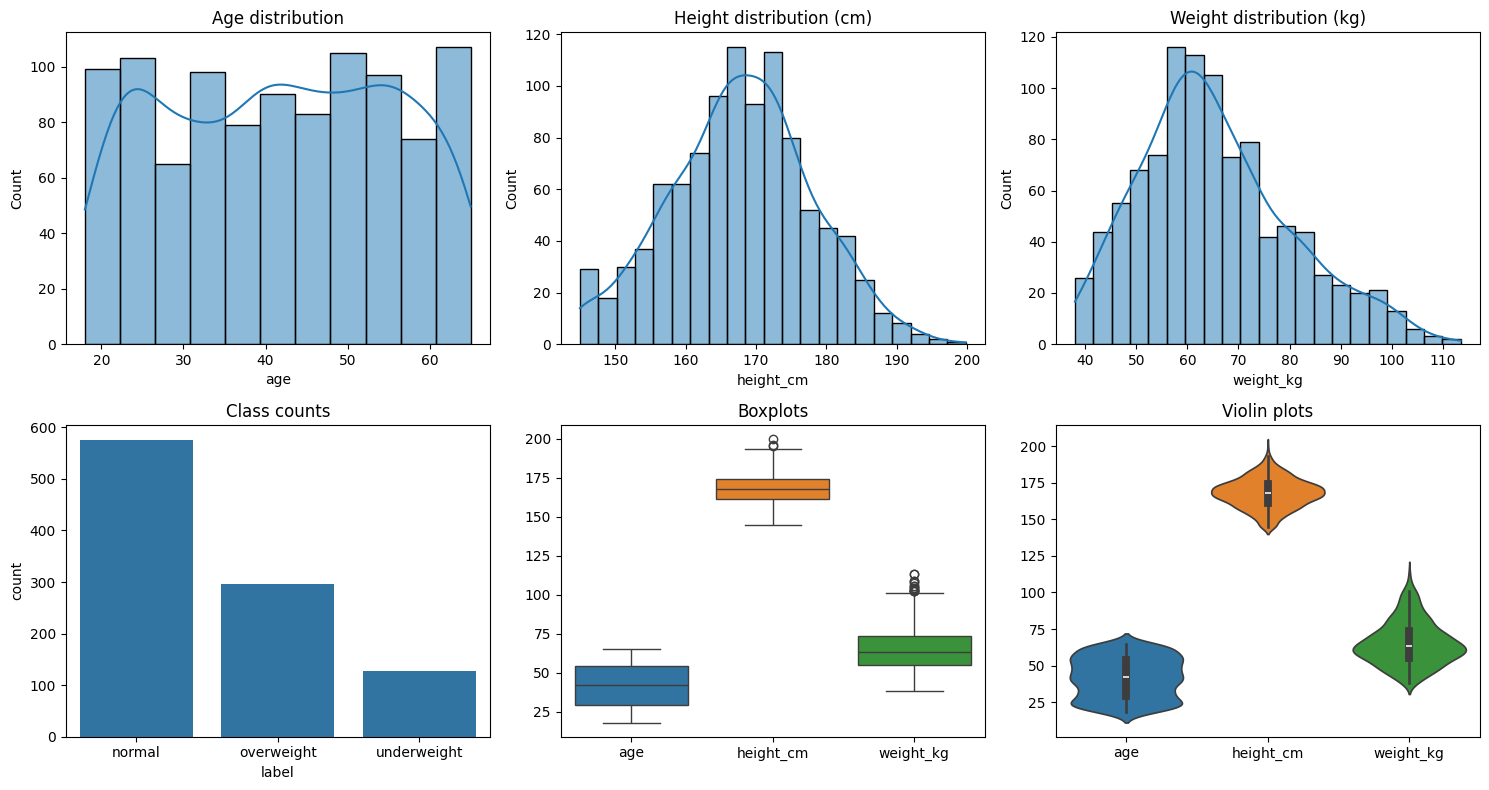

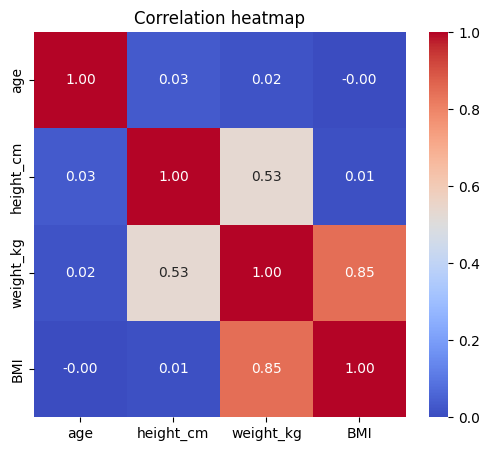

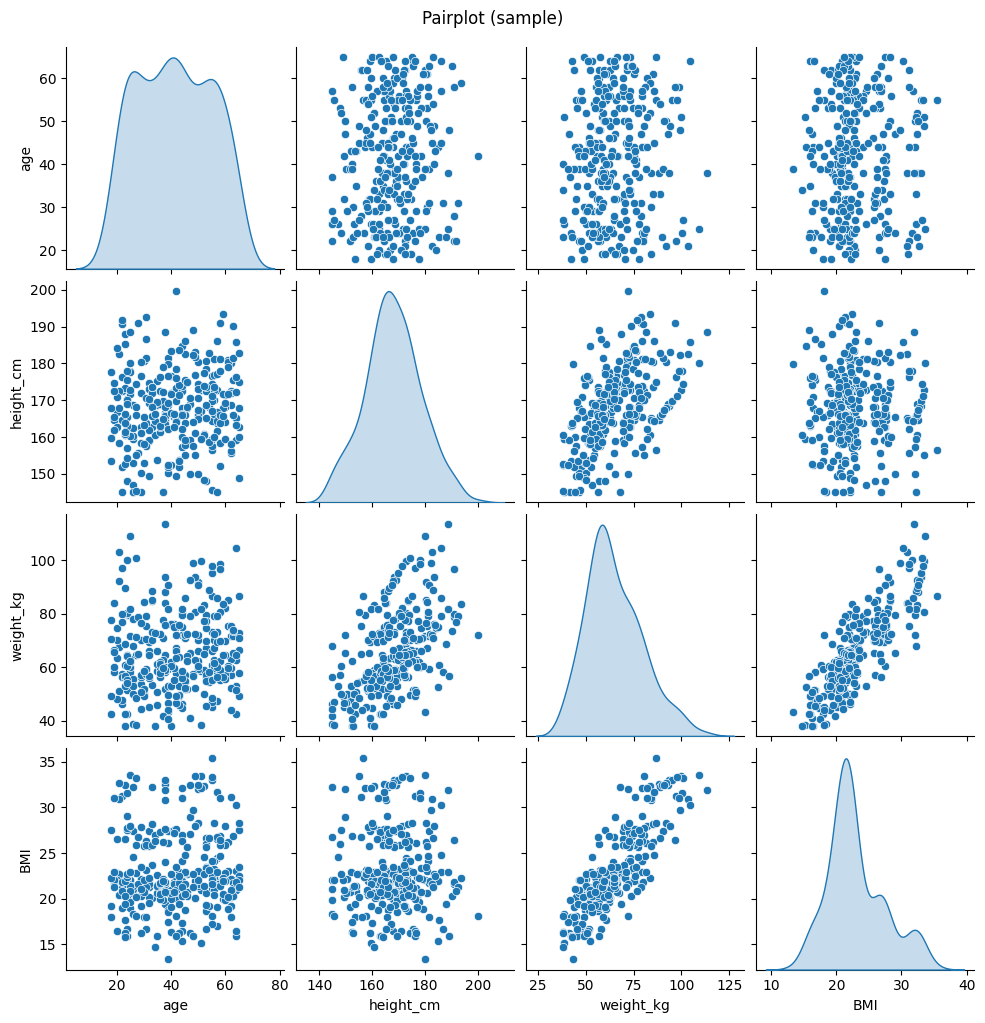


[KQ 5 mô hình ML cơ bản]
          model    acc    mae    mse      rmse
0        LogReg  0.985  0.015  0.015  0.122474
1       SVM-RBF  0.970  0.030  0.030  0.173205
3  DecisionTree  0.920  0.080  0.080  0.282843
4  RandomForest  0.895  0.105  0.105  0.324037
2           KNN  0.795  0.205  0.205  0.452769


<Figure size 450x400 with 0 Axes>

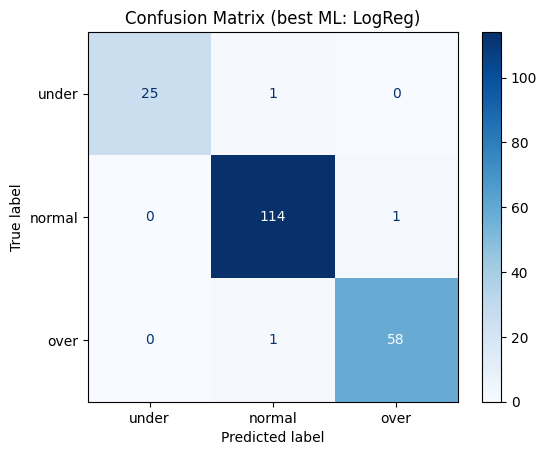


[KQ mô hình DL (CNN/RNN/LSTM)]
  model   acc   mae   mse      rmse
1   RNN  0.99  0.01  0.01  0.100000
0   CNN  0.97  0.03  0.03  0.173205
2  LSTM  0.60  0.40  0.40  0.632456

[BẢNG SO SÁNH TỔNG HỢP]
          model    acc    mae    mse      rmse type
5           RNN  0.990  0.010  0.010  0.100000   DL
0        LogReg  0.985  0.015  0.015  0.122474   ML
6           CNN  0.970  0.030  0.030  0.173205   DL
1       SVM-RBF  0.970  0.030  0.030  0.173205   ML
2  DecisionTree  0.920  0.080  0.080  0.282843   ML
3  RandomForest  0.895  0.105  0.105  0.324037   ML
4           KNN  0.795  0.205  0.205  0.452769   ML
7          LSTM  0.600  0.400  0.400  0.632456   DL


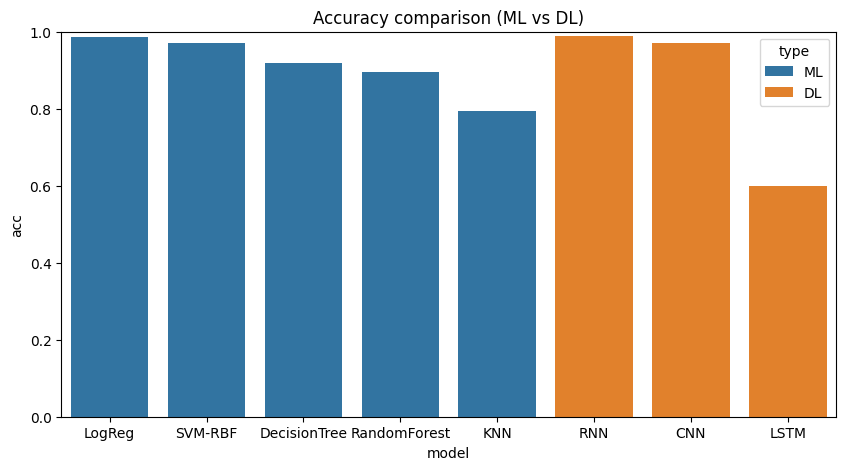

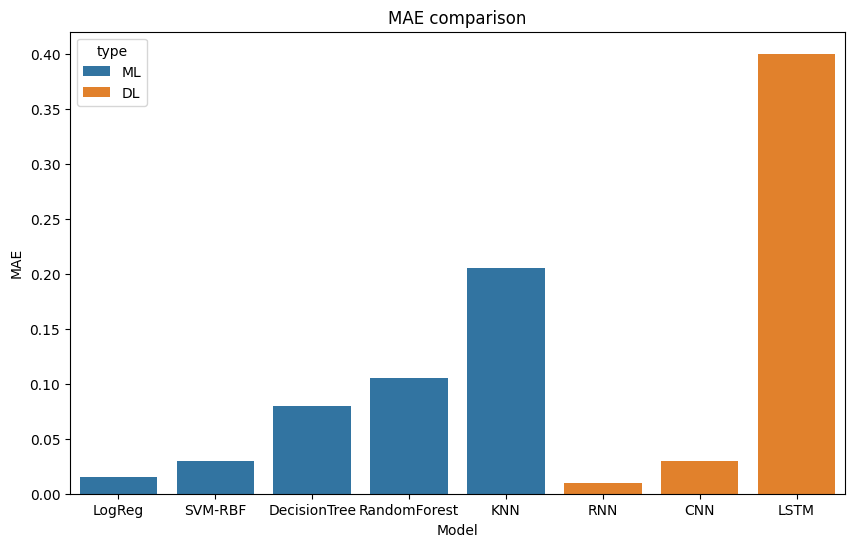

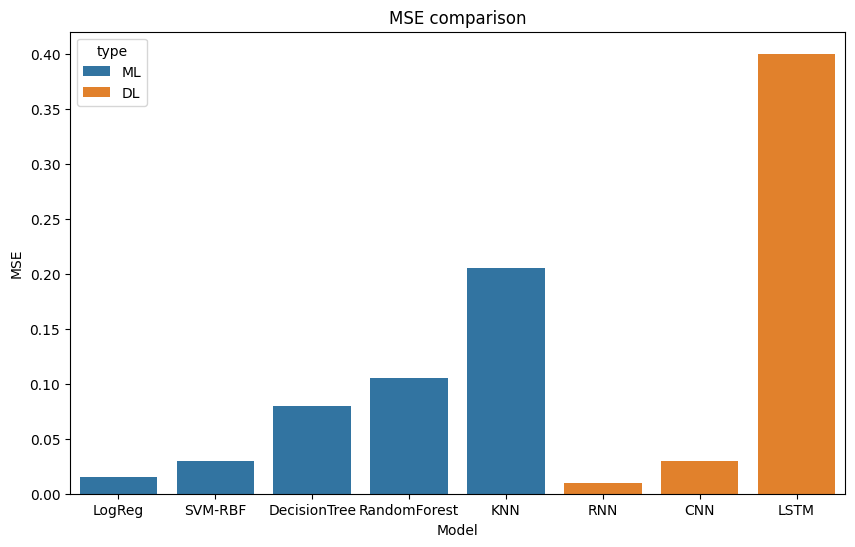

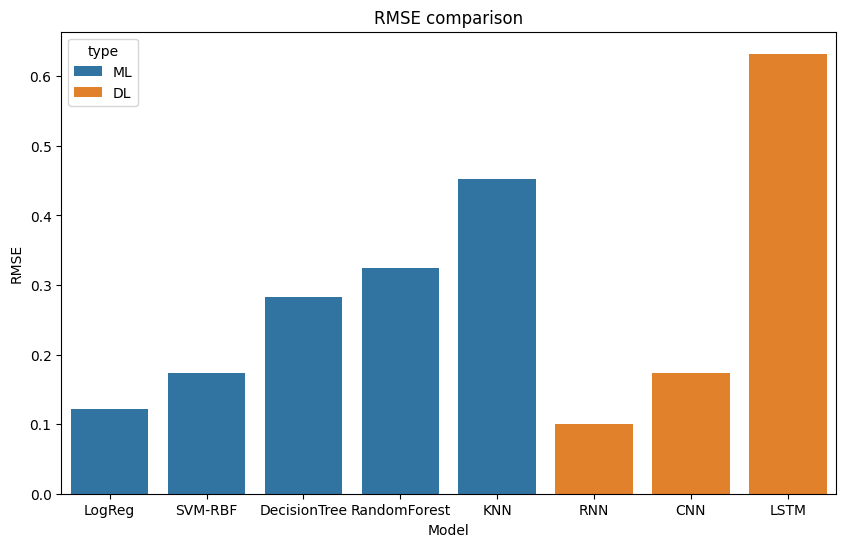

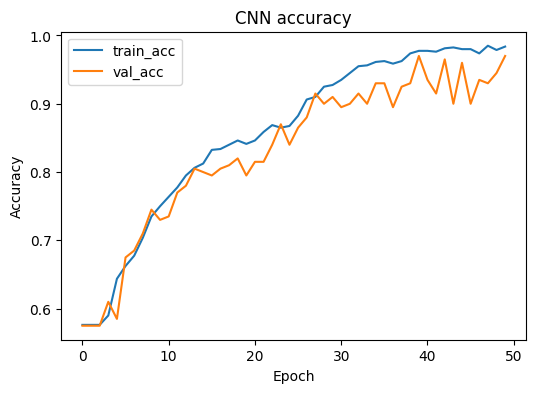

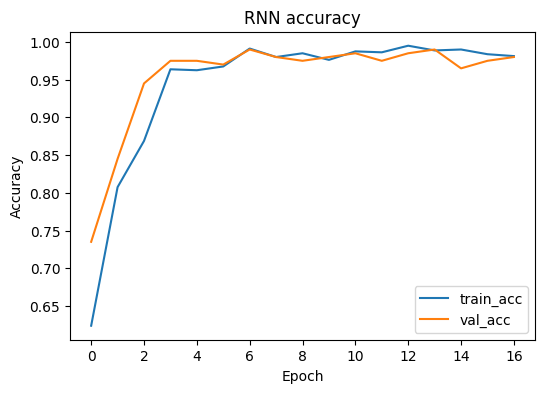

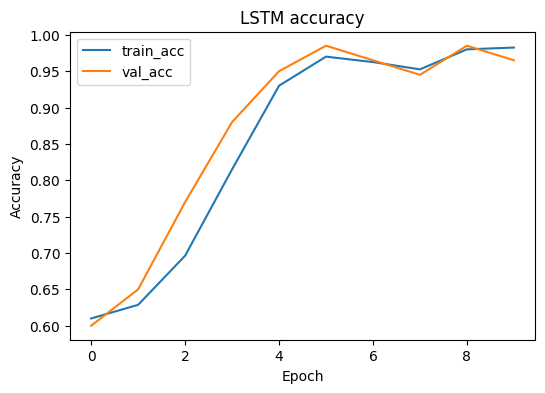


[DEPLOY] Best model: DL - RNN | acc=0.9900


Nhập nghề nghiệp (VD: IT, Student, Office...):  IT
Nhập tuổi:  21
Nhập chiều cao (cm):  172
Nhập cân nặng (kg):  72



[KẾT QUẢ DỰ ĐOÁN & TƯ VẤN]
{
  "input": {
    "job": "IT",
    "age": 21,
    "height_cm": 172.0,
    "weight_kg": 72.0
  },
  "BMI": 24.3,
  "rule_label": "normal",
  "model_label": "normal",
  "advice": [
    "Duy trì chế độ ăn cân bằng, nhiều rau củ quả (≥400 g/ngày).",
    "Hoạt động thể lực: ≥150 phút/tuần mức vừa hoặc ≥75 phút/tuần mức mạnh; tập tăng cơ ≥2 ngày/tuần.",
    "Hạn chế đồ uống có đường và thực phẩm siêu chế biến.",
    "Duy trì thói quen ngủ đủ giấc, quản lý stress."
  ]
}


In [11]:
#Đỗ Ngọc Lâm - B22DCCN476
# =========================
# (b)→(g) ALL-IN-ONE CELL
# =========================
import os, json, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# 5 mô hình ML cơ bản
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -------------------------
# ĐƯỜNG DẪN
# -------------------------
DATA_DIR = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4"
DATA_PATH = os.path.join(DATA_DIR, "data_4.1.csv")
KB_PATH   = os.path.join(DATA_DIR, "kb_healthGuide.json")

assert os.path.exists(DATA_PATH), "Chưa thấy data_4.1.csv — hãy chạy Cell #1 trước!"

# -------------------------
# (b) Show the distribution
# -------------------------
df = pd.read_csv(DATA_PATH)

# Tính BMI và nhãn (gộp obesity vào 'overweight' theo đề)
def bmi_from_hw(h_cm, w_kg):
    return w_kg / ((h_cm/100.0)**2)

df["BMI"] = bmi_from_hw(df["height_cm"], df["weight_kg"])

def bmi_label(bmi):
    if bmi < 18.5:
        return "underweight"
    elif bmi < 25:
        return "normal"
    else:
        return "overweight"  # gộp >=25 (bao gồm obese) vào overweight
df["label"] = df["BMI"].apply(bmi_label)

print("Phân phối nhãn:")
print(df["label"].value_counts())

# Hiển thị phân phối (>=5 loại biểu đồ)
plt.figure(figsize=(15,8))
plt.subplot(2,3,1); sns.histplot(df["age"], kde=True); plt.title("Age distribution")
plt.subplot(2,3,2); sns.histplot(df["height_cm"], kde=True); plt.title("Height distribution (cm)")
plt.subplot(2,3,3); sns.histplot(df["weight_kg"], kde=True); plt.title("Weight distribution (kg)")
plt.subplot(2,3,4); sns.countplot(data=df, x="label"); plt.title("Class counts")
plt.subplot(2,3,5); sns.boxplot(data=df[["age","height_cm","weight_kg"]]); plt.title("Boxplots")
plt.subplot(2,3,6); sns.violinplot(data=df[["age","height_cm","weight_kg"]]); plt.title("Violin plots")
plt.tight_layout()
plt.show()

# Heatmap tương quan
plt.figure(figsize=(6,5))
sns.heatmap(df[["age","height_cm","weight_kg","BMI"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

# Pairplot (một loại hình nữa)
sns.pairplot(df[["age","height_cm","weight_kg","BMI"]].sample(min(300,len(df))), diag_kind="kde")
plt.suptitle("Pairplot (sample)", y=1.02)
plt.show()


# --------------------------------------------------------
# Chuẩn bị dữ liệu cho học máy
# --------------------------------------------------------
X = df[["job", "age", "height_cm", "weight_kg"]]
y = df["label"].map({"underweight":0, "normal":1, "overweight":2}).astype(int)  # encode 3 lớp thành 0/1/2

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=7)

cat_cols = ["job"]
num_cols = ["age","height_cm","weight_kg"]

preprocess = ColumnTransformer([
    ("ohe", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("scaler", StandardScaler(), num_cols)
])

# --------------------------------------------------------
# (c) 5 mô hình ML cơ bản
# --------------------------------------------------------
ml_models = {
    "LogReg": LogisticRegression(max_iter=200),
    "SVM-RBF": SVC(kernel="rbf", probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "DecisionTree": DecisionTreeClassifier(max_depth=6, random_state=7),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=7)
}

ml_results = []
ml_pipelines = {}

for name, model in ml_models.items():
    pipe = Pipeline([("prep", preprocess), ("clf", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = math.sqrt(mse)
    ml_results.append({"model": name, "acc": acc, "mae": mae, "mse": mse, "rmse": rmse})
    ml_pipelines[name] = pipe

ml_df = pd.DataFrame(ml_results).sort_values("acc", ascending=False)
print("\n[KQ 5 mô hình ML cơ bản]")
print(ml_df)

# Confusion matrix cho mô hình ML tốt nhất
best_ml_name = ml_df.iloc[0]["model"]
best_ml = ml_pipelines[best_ml_name]
y_pred_best_ml = best_ml.predict(X_val)

plt.figure(figsize=(4.5,4))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_best_ml, display_labels=["under","normal","over"], cmap="Blues")
plt.title(f"Confusion Matrix (best ML: {best_ml_name})")
plt.show()


# --------------------------------------------------------
# (d) 3 mô hình DL: CNN, RNN, LSTM — mỗi mô hình 5 tầng
# - Ta dùng dữ liệu tabular -> reshape thành chuỗi dài n_features để dùng Conv1D/RNN/LSTM
# --------------------------------------------------------
# Chuẩn hóa/OneHot -> mảng numpy
X_train_t = preprocess.fit_transform(X_train)
X_val_t   = preprocess.transform(X_val)

n_features = X_train_t.shape[1]
num_classes = 3

# Reshape thành (samples, steps, channels=1)
X_train_seq = np.asarray(X_train_t.todense() if hasattr(X_train_t, "todense") else X_train_t)
X_val_seq   = np.asarray(X_val_t.todense() if hasattr(X_val_t, "todense") else X_val_t)

X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], n_features, 1))
X_val_seq   = X_val_seq.reshape((X_val_seq.shape[0], n_features, 1))

y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_val_oh   = keras.utils.to_categorical(y_val, num_classes)

def build_cnn(input_shape, n_classes):
    # 5 TẦNG: Input -> Conv1D -> Conv1D -> GlobalAvgPool1D -> Dense -> Dense
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv1D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.Conv1D(32, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="cnn_1d")
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def build_rnn(input_shape, n_classes):
    # 5 TẦNG: Input -> SimpleRNN -> Dense -> Dense -> Dense
    inputs = keras.Input(shape=input_shape)
    x = layers.SimpleRNN(64, return_sequences=False)(inputs)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="rnn_simple")
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def build_lstm(input_shape, n_classes):
    # 5 TẦNG: Input -> LSTM -> Dense -> Dense -> Dense
    inputs = keras.Input(shape=input_shape)
    x = layers.LSTM(64, return_sequences=False)(inputs)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="lstm_1")
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

cnn = build_cnn((n_features,1), num_classes)
rnn = build_rnn((n_features,1), num_classes)
lstm = build_lstm((n_features,1), num_classes)

early = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_accuracy")

hist_cnn = cnn.fit(X_train_seq, y_train_oh, validation_data=(X_val_seq, y_val_oh),
                   epochs=60, batch_size=32, verbose=0, callbacks=[early])
hist_rnn = rnn.fit(X_train_seq, y_train_oh, validation_data=(X_val_seq, y_val_oh),
                   epochs=60, batch_size=32, verbose=0, callbacks=[early])
hist_lstm = lstm.fit(X_train_seq, y_train_oh, validation_data=(X_val_seq, y_val_oh),
                     epochs=60, batch_size=32, verbose=0, callbacks=[early])

def eval_dl(model, name):
    y_pred_prob = model.predict(X_val_seq, verbose=0)
    y_pred = y_pred_prob.argmax(axis=1)
    acc = accuracy_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = math.sqrt(mse)
    return {"model": name, "acc": acc, "mae": mae, "mse": mse, "rmse": rmse}, y_pred

dl_results = []
for mdl, nm in [(cnn,"CNN"), (rnn,"RNN"), (lstm,"LSTM")]:
    res, _ = eval_dl(mdl, nm)
    dl_results.append(res)

dl_df = pd.DataFrame(dl_results).sort_values("acc", ascending=False)
print("\n[KQ mô hình DL (CNN/RNN/LSTM)]")
print(dl_df)

# So sánh tất cả mô hình (c & d)
all_df = pd.concat([ml_df.assign(type="ML"), dl_df.assign(type="DL")], ignore_index=True)
print("\n[BẢNG SO SÁNH TỔNG HỢP]")
print(all_df.sort_values(["acc","type"], ascending=[False, True]))

# (e) Vẽ biểu đồ so sánh metrics
plt.figure(figsize=(10,5))
sns.barplot(data=all_df, x="model", y="acc", hue="type")
plt.title("Accuracy comparison (ML vs DL)")
plt.ylim(0,1)
plt.show()

# MAE
plt.figure(figsize=(10,6))
sns.barplot(data=all_df, x="model", y="mae", hue="type")
plt.title("MAE comparison")
plt.ylabel("MAE")
plt.xlabel("Model")
plt.show()

# MSE
plt.figure(figsize=(10,6))
sns.barplot(data=all_df, x="model", y="mse", hue="type")
plt.title("MSE comparison")
plt.ylabel("MSE")
plt.xlabel("Model")
plt.show()

# RMSE
plt.figure(figsize=(10,6))
sns.barplot(data=all_df, x="model", y="rmse", hue="type")
plt.title("RMSE comparison")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.show()

# Learning curves (thêm 1 biểu đồ dạng line)
def plot_history(h, title):
    plt.figure(figsize=(6,4))
    plt.plot(h.history["accuracy"], label="train_acc")
    plt.plot(h.history["val_accuracy"], label="val_acc")
    plt.title(title)
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.show()
plot_history(hist_cnn, "CNN accuracy")
plot_history(hist_rnn, "RNN accuracy")
plot_history(hist_lstm, "LSTM accuracy")


# --------------------------------------------------------
# (f) Đủ >=5 loại biểu đồ đã có:
#   - hist (age/height/weight), countplot (label), boxplot, violin, heatmap corr,
#     pairplot, confusion matrix, barplot metrics, learning curves (line).
# --------------------------------------------------------


# --------------------------------------------------------
# (g) Deploy best model + Health Guide (KB JSON)
# --------------------------------------------------------

# 1) Chọn mô hình tốt nhất theo accuracy (ưu tiên DL, nếu bằng thì lấy DL)
best_row = all_df.sort_values(["acc","type"], ascending=[False, True]).iloc[0]
best_name = best_row["model"]
best_type = best_row["type"]

if best_type == "ML":
    best_model = ml_pipelines[best_name]
    use_dl = False
else:
    # map tên -> model
    m = {"CNN": cnn, "RNN": rnn, "LSTM": lstm}
    best_model = m[best_name]
    use_dl = True

print(f"\n[DEPLOY] Best model: {best_type} - {best_name} | acc={best_row['acc']:.4f}")

# 2) Knowledge Base: nếu chưa có file, tạo với nội dung chuẩn (WHO/CDC)
DEFAULT_KB = {
    "bmi_categories": {
        "underweight": "BMI < 18.5",
        "normal": "18.5 ≤ BMI < 25",
        "overweight": "BMI ≥ 25"
    },
    "advice": {
        "underweight": [
            "Tăng năng lượng lành mạnh: thêm ngũ cốc nguyên hạt, các loại hạt và dầu lành mạnh.",
            "Ăn đủ đạm (thịt nạc, trứng, sữa chua, đậu).",
            "Chia nhỏ bữa, thêm snack giàu dinh dưỡng.",
            "Theo dõi cân nặng, giấc ngủ; khám chuyên khoa nếu sụt cân nhanh."
        ],
        "normal": [
            "Duy trì chế độ ăn cân bằng, nhiều rau củ quả (≥400 g/ngày).",
            "Hoạt động thể lực: ≥150 phút/tuần mức vừa hoặc ≥75 phút/tuần mức mạnh; tập tăng cơ ≥2 ngày/tuần.",
            "Hạn chế đồ uống có đường và thực phẩm siêu chế biến.",
            "Duy trì thói quen ngủ đủ giấc, quản lý stress."
        ],
        "overweight": [
            "Thiết lập mục tiêu giảm cân thực tế, theo dõi khẩu phần và calo.",
            "Tăng rau củ quả; giảm đường, muối, chất béo bão hòa.",
            "Hoạt động thể lực theo khuyến nghị (≥150 phút/tuần + 2 ngày tăng cơ).",
            "Kết hợp ngủ đủ, quản lý stress; cân nhắc tư vấn dinh dưỡng y khoa nếu cần."
        ]
    },
    "sources": [
        "WHO BMI cutoffs, CDC BMI categories",
        "WHO healthy diet (≥400g rau quả/ngày)",
        "CDC & WHO physical activity (≥150 phút/tuần)"
    ]
}

# Ghi KB nếu chưa có
os.makedirs(DATA_DIR, exist_ok=True)
if not os.path.exists(KB_PATH):
    with open(KB_PATH, "w", encoding="utf-8") as f:
        json.dump(DEFAULT_KB, f, ensure_ascii=False, indent=2)

with open(KB_PATH, "r", encoding="utf-8") as f:
    KB = json.load(f)

# 3) Hàm suy luận + tư vấn
#    Đầu vào: job, age, height(cm), weight(kg)
#    Đầu ra: class + hướng dẫn sức khỏe từ KB
def predict_and_guide(job: str, age: int, height_cm: float, weight_kg: float):
    # Tính BMI và label theo rule
    bmi = weight_kg / ((height_cm/100.0)**2)
    if bmi < 18.5:
        lbl_rule = "underweight"
    elif bmi < 25:
        lbl_rule = "normal"
    else:
        lbl_rule = "overweight"

    # Dự đoán theo mô hình tốt nhất
    X_new = pd.DataFrame([{"job": job, "age": age, "height_cm": height_cm, "weight_kg": weight_kg}])

    if use_dl:
        # preprocess -> seq
        X_new_t = preprocess.transform(X_new)
        X_new_seq = np.asarray(X_new_t.todense() if hasattr(X_new_t, "todense") else X_new_t).reshape(1, -1, 1)
        probs = best_model.predict(X_new_seq, verbose=0)[0]
        pred_id = int(np.argmax(probs))
    else:
        probs = None
        pred_id = int(best_model.predict(X_new)[0])

    inv_map = {0:"underweight", 1:"normal", 2:"overweight"}
    pred_lbl = inv_map[pred_id]

    # Tư vấn từ KB
    advice_list = KB.get("advice", {}).get(pred_lbl, [])
    result = {
        "input": {"job": job, "age": age, "height_cm": height_cm, "weight_kg": weight_kg},
        "BMI": round(bmi, 1),
        "rule_label": lbl_rule,
        "model_label": pred_lbl,
        "advice": advice_list
    }
    return result

# Demo triển khai
# Người dùng nhập từ console
job = input("Nhập nghề nghiệp (VD: IT, Student, Office...): ")
age = int(input("Nhập tuổi: "))
height_cm = float(input("Nhập chiều cao (cm): "))
weight_kg = float(input("Nhập cân nặng (kg): "))

result = predict_and_guide(job=job, age=age, height_cm=height_cm, weight_kg=weight_kg)

print("\n[KẾT QUẢ DỰ ĐOÁN & TƯ VẤN]")
print(json.dumps(result, ensure_ascii=False, indent=2))

